# Multi Agents - 자율 연구 에이전트
LangGraph를 활용하여 동적 워크플로우, 루프/재귀, Human-in-the-loop 패턴을 구현하는 자율 연구 시스템을 만듭니다.

## 구성
1. **계획 에이전트**: 연구 주제 분석 및 계획 수립
2. **검색 에이전트**: 정보 수집 및 자료 검색
3. **분석 에이전트**: 수집된 데이터 분석
4. **검증 에이전트**: 정보의 신뢰성과 완성도 검증
5. **조정 에이전트**: 추가 조사 필요 여부 판단 및 워크플로우 제어
6. **보고서 에이전트**: 최종 연구 보고서 작성

## 학습 목표
- 동적 워크플로우 (Dynamic Workflow): 실행 중 경로 변경
- 루프와 재귀 (Loop & Recursion): 조건에 따라 반복 실행
- Human-in-the-loop (HITL): 중요한 결정에 사용자 개입


## 1. LLM


### API 키 설정
- [OpenAI API 키](https://platform.openai.com/api-keys)
- [Tavily API 키](https://tavily.com/) - 실제 웹 검색 기능 사용 (선택사항)

In [1]:
from dotenv import load_dotenv

load_dotenv()

True

In [2]:
import os

# API 키 확인
openai_key = os.getenv("OPENAI_API_KEY")
tavily_key = os.getenv("TAVILY_API_KEY")

if openai_key:
    print("OpenAI API 키가 설정되었습니다. (GPT 모델 사용)")
else:
    print("OpenAI API 키가 없습니다.")

if tavily_key:
    print("Tavily API 키가 설정되었습니다. (웹 검색 사용)")
else:
    print("Tavily API 키가 없습니다. (검색 기능이 시뮬레이션 모드로 작동합니다)")

OpenAI API 키가 설정되었습니다. (GPT 모델 사용)
Tavily API 키가 설정되었습니다. (웹 검색 사용)


### LLM 초기화

In [3]:
from langchain_openai import ChatOpenAI

llm = ChatOpenAI(
    model="gpt-5-nano",
    reasoning_effort="high",        # 논리성 강화
)

### Tavily 검색 도구 초기화 (실제 웹 검색용)

In [4]:
from langchain_tavily import TavilySearch

tavily_search = TavilySearch(
    max_results=3,
    topic="general",               # 또는 "news", "finance" 등
    include_answer=True,           # 답변 포함 여부
    include_raw_content=True,     # 원본 내용 포함 여부
    include_images=False,          # 이미지 포함 여부
    search_depth="basic",          # "basic" 또는 "advanced"
    include_domains=[
        "https://www.naver.com", # 뉴스
        "https://www.weatheri.co.kr/", # 날씨 
        "https://kr.investing.com/equities/south-korea" # 주식
    ],
    exclude_domains=None            # 필요하면 제외 도메인 지정 가능
)

## 2. 상태 정의 (State Management)

고급 워크플로우를 위한 복잡한 상태 구조를 정의합니다. 루프 제어, 이력 관리, 검증 상태 등을 포함합니다.


In [5]:
from typing import TypedDict, List, Literal, Annotated
from operator import add

class ResearchState(TypedDict):
    """
    자율 연구 시스템의 상태를 정의하는 클래스
    
    Attributes:
        topic: 연구 주제
        research_plan: 연구 계획
        search_results: 검색 결과 리스트 (누적)
        analysis_results: 분석 결과 리스트 (누적)
        verification_status: 검증 상태 (passed/failed)
        verification_feedback: 검증 피드백
        needs_more_research: 추가 연구 필요 여부
        iteration_count: 반복 횟수 (무한 루프 방지)
        max_iterations: 최대 반복 횟수 (주제 복잡도에 따라 동적 설정)
        human_approval: 사용자 승인 여부
        final_report: 최종 보고서
    """
    topic: str
    research_plan: str
    search_results: Annotated[List[str], add]  # 누적 집계
    analysis_results: Annotated[List[str], add]  # 누적 집계
    verification_status: str
    verification_feedback: str
    needs_more_research: bool
    iteration_count: int
    max_iterations: int  # 동적 최대 반복 횟수
    human_approval: bool
    final_report: str
    

## 3. 에이전트 노드 정의


### 3.1 계획 에이전트


In [6]:
from langchain_core.messages import HumanMessage, SystemMessage

def planning_agent(state: ResearchState) -> dict:
    """
    연구 주제를 분석하고 상세한 연구 계획을 수립하는 에이전트
    주제의 복잡도를 평가하여 최대 반복 횟수를 동적으로 설정
    """
    topic = state["topic"]
    iteration = state.get("iteration_count", 0)
    
    # 첫 번째 반복인 경우 주제 복잡도 평가
    if iteration == 0:
        complexity_messages = [
            SystemMessage(content="""
                당신은 연구 주제 복잡도 평가 전문가입니다.
                주어진 주제의 복잡도를 평가하세요:

                - SIMPLE: 단순하고 명확한 주제 (예: 특정 기술 소개, 단일 개념 설명)
                - MODERATE: 중간 복잡도 주제 (예: 기술 비교, 트렌드 분석)
                - COMPLEX: 복잡한 주제 (예: 다면적 분석, 미래 예측, 철학적 논의)

                반드시 "COMPLEXITY: SIMPLE", "COMPLEXITY: MODERATE", "COMPLEXITY: COMPLEX" 중 하나로 시작하세요."""),
            HumanMessage(content=f"주제: {topic}\n\n이 주제의 복잡도를 평가하세요.")
        ]
        
        complexity_response = llm.invoke(complexity_messages)
        complexity_text = complexity_response.content
        
        # 복잡도에 따른 최대 반복 횟수 설정
        if "COMPLEXITY: SIMPLE" in complexity_text:
            max_iterations = 2
            complexity_level = "단순"
        elif "COMPLEXITY: COMPLEX" in complexity_text:
            max_iterations = 4
            complexity_level = "복잡"
        else:
            max_iterations = 3
            complexity_level = "중간"
        
        print(f"[계획 에이전트] 주제 복잡도: {complexity_level} (최대 {max_iterations}회 반복)")
    else:
        max_iterations = state.get("max_iterations", 3)
    
    # 재연구인 경우 피드백 반영
    feedback = state.get("verification_feedback", "")
    feedback_context = f"\n\n이전 피드백: {feedback}" if feedback else ""
    
    messages = [
        SystemMessage(content="""
            당신은 연구 계획 전문가입니다.
            주어진 주제에 대해 체계적인 연구 계획을 수립하세요:
            1. 핵심 조사 질문 정의
            2. 필요한 정보 유형 파악
            3. 검색 키워드 제안
            4. 분석 방향 제시

            간결하고 실행 가능한 계획을 작성하세요."""),
        HumanMessage(content=f"주제: {topic}{feedback_context}\n\n연구 계획을 수립하세요.")
    ]
    
    response = llm.invoke(messages)
    plan = response.content
    
    print(f"[계획 에이전트] 연구 계획 수립 완료 (반복 {iteration + 1}회 / 최대 {max_iterations}회)")
    
    return {
        "research_plan": plan,
        "iteration_count": iteration + 1,
        "max_iterations": max_iterations
    }


### 3.2 검색 에이전트 (TavilySearchResults 사용)

실제 웹 검색을 수행하는 에이전트입니다. 

**TavilySearchResults 사용:**
- Tavily API 키가 있으면 실제 웹 검색 수행
- Tavily API 키가 없으면 시뮬레이션 모드로 작동
- API 키 발급: [Tavily](https://tavily.com/)

**참고:** Tavily API 키를 설정하려면 위의 API 키 설정 셀에서 주석을 제거하고 키를 입력하세요.


In [7]:
def search_agent(state: ResearchState) -> dict:
    """
    연구 계획에 따라 정보를 검색하고 수집하는 에이전트
    TavilySearchResults를 사용하여 실제 웹 검색 수행
    """
    topic = state["topic"]
    iteration = state['iteration_count']
    
    # Tavily 검색이 가능한 경우 실제 웹 검색 수행
    # 검색 쿼리 생성 (주제 + 계획의 핵심 키워드)
    search_query = f"{topic}"
    
    print(f"[검색 에이전트] 웹 검색 실행: {search_query}")
    
    # 실제 웹 검색 수행
    search_results_raw = tavily_search.invoke({"query": search_query})
    
    # 검색 결과를 포맷팅
    formatted_results = []
    for i, result in enumerate(search_results_raw['results'], 1):
        url = result.get('url', 'N/A')
        content = result.get('content', 'N/A')
        formatted_results.append(f"출처 {i}: {url}\n내용: {content}")
    
    search_result_text = "\n\n".join(formatted_results)
    
    # LLM을 사용하여 검색 결과 요약 및 분석
    summary_messages = [
        SystemMessage(content="""
        당신은 정보 분석 전문가입니다.
        웹 검색 결과를 분석하여 연구 주제와 관련된 핵심 정보를 요약하세요.
        - 각 출처의 주요 내용 정리
        - 관련성 높은 정보 강조
        - 상충되는 정보가 있다면 명시"""),
        HumanMessage(content=f"""
        주제: {topic}
        
        검색 결과:
        {search_result_text}
        
        이 결과를 요약하고 분석하세요.""")
    ]
    
    summary_response = llm.invoke(summary_messages)
    
    search_result = f"""
    [실제 웹 검색 결과 - 반복 {iteration}]
    
    {summary_response.content}
    
    --- 원본 검색 결과 ---
    {search_result_text[:500]}..."""
    
    print(f"[검색 에이전트] 실제 웹 검색 완료 ({len(search_results_raw)}개 결과)")
    
    return {
        "search_results": [search_result]
    }


### 3.3 분석 에이전트


In [8]:
def analysis_agent(state: ResearchState) -> dict:
    """
    수집된 정보를 분석하고 인사이트를 도출하는 에이전트
    """
    topic = state["topic"]
    search_results = state["search_results"]
    
    # 최신 검색 결과만 분석 (또는 전체 분석)
    recent_results = "\n\n".join(search_results[-3:])  # 최근 3개
    
    messages = [
        SystemMessage(content="""
            당신은 데이터 분석 전문가입니다.
            수집된 정보를 분석하여:
            1. 핵심 패턴과 트렌드 파악
            2. 주요 발견사항 정리
            3. 상충되는 정보 식별
            4. 추가 조사가 필요한 부분 지적

            분석적이고 비판적인 관점을 유지하세요."""),
        HumanMessage(content=f"주제: {topic}\n\n검색 결과:\n{recent_results}\n\n이 정보를 분석하세요.")
    ]
    
    response = llm.invoke(messages)
    analysis = f"[분석 결과 - 반복 {state['iteration_count']}]\n{response.content}"
    
    print(f"[분석 에이전트] 데이터 분석 완료")
    
    return {
        "analysis_results": [analysis]
    }


### 3.4 검증 에이전트


In [9]:
def verification_agent(state: ResearchState) -> dict:
    """
    정보의 신뢰성과 완성도를 검증하는 에이전트
    """
    topic = state["topic"]
    analysis_results = state["analysis_results"]
    
    # 최신 분석 결과 검토
    recent_analysis = "\n\n".join(analysis_results[-2:])
    
    messages = [
        SystemMessage(content="""
            당신은 연구 품질 검증 전문가입니다.
            분석 결과를 검토하고 다음을 판단하세요:
            1. 정보의 충분성 (충분한가?)
            2. 정보의 신뢰성 (출처가 믿을만한가?)
            3. 논리의 일관성 (모순이 없는가?)
            4. 추가 조사 필요 여부

            반드시 다음 형식으로 시작하세요:
            STATUS: PASSED 또는 STATUS: NEEDS_MORE_RESEARCH

            그 다음 상세한 피드백을 제공하세요."""),
        HumanMessage(content=f"주제: {topic}\n\n분석 결과:\n{recent_analysis}\n\n검증 결과를 제공하세요.")
    ]
    
    response = llm.invoke(messages)
    verification_result = response.content
    
    # 검증 상태 파싱
    if "STATUS: PASSED" in verification_result:
        status = "passed"
        needs_more = False
        print(f"[검증 에이전트] 검증 통과")
    else:
        status = "needs_more_research"
        needs_more = True
        print(f"[검증 에이전트] 추가 조사 필요")
    
    return {
        "verification_status": status,
        "verification_feedback": verification_result,
        "needs_more_research": needs_more
    }


### 3.5 조정 에이전트


In [10]:
def coordination_agent(state: ResearchState) -> dict:
    """
    워크플로우를 제어하고 다음 단계를 결정하는 에이전트
    동적으로 설정된 최대 반복 횟수를 사용
    """
    iteration = state["iteration_count"]
    needs_more = state["needs_more_research"]
    feedback = state["verification_feedback"]
    max_iterations = state.get("max_iterations", 3)  # 동적 최대 반복 횟수
    
    if needs_more and iteration < max_iterations:
        print(f"[조정 에이전트] 추가 조사 필요 - 검색으로 돌아갑니다 (반복 {iteration}/{max_iterations})")
        return {}
    elif iteration >= max_iterations:
        print(f"[조정 에이전트] 최대 반복 횟수 도달 ({max_iterations}회) - 현재 결과로 진행합니다")
        return {
            "needs_more_research": False,
            "verification_status": "max_iterations_reached"
        }
    else:
        print(f"[조정 에이전트] 연구 완료 - 보고서 작성 단계로 진행")
        return {}

#### Human-in-the-loop 노드

In [11]:
# Human-in-the-loop 노드
def human_review_node(state: ResearchState) -> dict:
    """
    사용자의 승인을 받는 노드 (Human-in-the-loop)
    """
    print("\n" + "="*80)
    print("[Human-in-the-loop] 사용자 검토 요청")
    print("="*80)
    print(f"현재 반복: {state['iteration_count']}/{state.get('max_iterations', 3)}")
    print(f"검증 상태: {state['verification_status']}")
    print(f"\n검증 피드백:\n{state['verification_feedback']}")
    print("="*80)
    
    # 실제 구현에서는 input()을 사용하지만, 
    # 자동 테스트를 위해 기본값 제공
    user_input = input("\n계속 진행하시겠습니까? (yes/no, 기본값: yes): ").strip().lower()
    
    if not user_input:
        user_input = "yes"
    
    approval = user_input in ["yes", "y", ""]
    
    if approval:
        print("[Human-in-the-loop] 승인됨 - 계속 진행")
    else:
        print("[Human-in-the-loop] 거부됨 - 워크플로우 중단")
    
    return {
        "human_approval": approval
    }


### 3.6 보고서 에이전트


In [12]:
def report_agent(state: ResearchState) -> dict:
    """
    모든 연구 결과를 종합하여 최종 보고서를 작성하는 에이전트
    """
    topic = state["topic"]
    plan = state["research_plan"]
    all_search = "\n\n".join(state["search_results"])
    all_analysis = "\n\n".join(state["analysis_results"])
    iterations = state["iteration_count"]
    
    messages = [
        SystemMessage(content="""
            당신은 연구 보고서 작성 전문가입니다.
            수집되고 분석된 모든 정보를 종합하여 체계적인 최종 보고서를 작성하세요:

            1. 요약 (Executive Summary)
            2. 연구 배경 및 목적
            3. 주요 발견사항
            4. 상세 분석
            5. 결론 및 제언
            6. 한계점 및 향후 연구 방향

            전문적이고 명확한 보고서를 작성하세요."""),
        HumanMessage(content=f"""
            주제: {topic}

            연구 계획:
            {plan}

            검색 결과:
            {all_search}

            분석 결과:
            {all_analysis}

            (총 {iterations}회 반복 조사 수행)

            위 내용을 바탕으로 최종 보고서를 작성하세요.""")
    ]
    
    response = llm.invoke(messages)
    report = response.content
    
    print(f"[보고서 에이전트] 최종 보고서 작성 완료")
    
    return {
        "final_report": report
    }


## 4. 동적 라우팅 함수

조건에 따라 다음 노드를 동적으로 결정하는 라우팅 함수들을 정의합니다.


In [13]:
def route_after_verification(state: ResearchState) -> Literal["human_review", "coordination"]:
    """
    검증 후 Human-in-the-loop 또는 조정으로 라우팅
    """
    max_iterations = state.get("max_iterations", 3)
    
    # 추가 연구가 필요하거나 최대 반복 도달 시 사람 검토
    needs_review = (
        state["needs_more_research"] or 
        state["iteration_count"] >= max_iterations
    )
    
    if needs_review:
        return "human_review"
    else:
        return "coordination"

In [14]:
def route_after_human_review(state: ResearchState) -> Literal["coordination", "report"]:
    """
    Human review 후 라우팅
    """
    if not state["human_approval"]:
        # 사용자가 거부한 경우 바로 보고서로 (중단)
        return "report"
    else:
        return "coordination"

In [15]:
def route_after_coordination(state: ResearchState) -> Literal["planning", "report"]:
    """
    조정 에이전트 후 루프 또는 종료 결정
    동적으로 설정된 최대 반복 횟수 사용
    """
    max_iterations = state.get("max_iterations", 3)
    
    # 추가 연구가 필요하고 최대 반복 미만이면 루프
    if state["needs_more_research"] and state["iteration_count"] < max_iterations:
        return "planning"  # 루프: 계획으로 돌아감
    else:
        return "report"  # 종료: 보고서 작성


## 5. 그래프 구성 (동적 워크플로우 + 루프)

복잡한 워크플로우를 구성합니다. 조건에 따라 경로가 변경되고, 필요시 루프를 돕니다.

### 그래프 구조
```
시작
  |
  v
계획 <----------+
  |             |
  v             |
검색            | (루프)
  |             |
  v             |
분석            |
  |             |
  v             |
검증            |
  |             |
  v             |
Human Review?   |
  |             |
  v             |
조정 -----------+
  |
  v
보고서
  |
  v
종료
```


In [16]:
from langgraph.graph import StateGraph, END

# StateGraph 생성
workflow = StateGraph(ResearchState)

# 노드 추가
workflow.add_node("planning", planning_agent)
workflow.add_node("search", search_agent)
workflow.add_node("analysis", analysis_agent)
workflow.add_node("verification", verification_agent)
workflow.add_node("human_review", human_review_node)
workflow.add_node("coordination", coordination_agent)
workflow.add_node("report", report_agent)

# 시작점 설정
workflow.set_entry_point("planning")

# 순차적 연결 (계획 -> 검색 -> 분석 -> 검증)
workflow.add_edge("planning", "search")
workflow.add_edge("search", "analysis")
workflow.add_edge("analysis", "verification")

# 검증 후 조건부 라우팅 (Human review 필요 여부)
workflow.add_conditional_edges(
    "verification",
    route_after_verification,
    {
        "human_review": "human_review",
        "coordination": "coordination"
    }
)

# Human review 후 라우팅
workflow.add_conditional_edges(
    "human_review",
    route_after_human_review,
    {
        "coordination": "coordination",
        "report": "report"
    }
)

# 조정 후 조건부 라우팅 (루프 또는 종료)
workflow.add_conditional_edges(
    "coordination",
    route_after_coordination,
    {
        "planning": "planning",  # 루프: 다시 계획으로
        "report": "report"       # 종료: 보고서로
    }
)

# 보고서에서 종료
workflow.add_edge("report", END)

# 그래프 컴파일
app = workflow.compile()



## 6. 그래프 시각화 (선택사항)


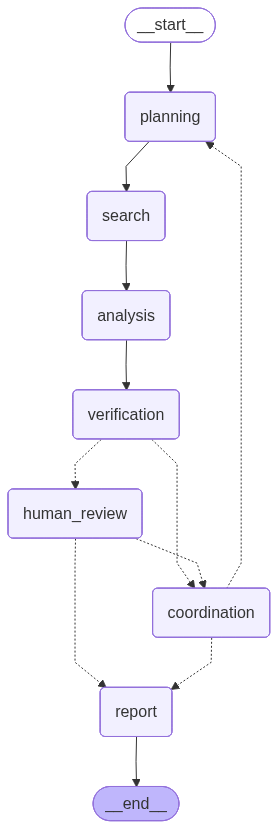

In [17]:
from IPython.display import Image, display

try:
    
    display(
        Image(
            app.get_graph().draw_mermaid_png()
        )
    )
except Exception as e:
    print(f"그래프 표시 오류: {e}")


## 7. 테스트 예제

자율 연구 시스템을 실행해봅니다.


### 7.1 연구 주제 설정


In [18]:
research_topic = "LangGraph를 활용한 Multi-Agent 시스템의 장단점과 실제 활용 사례"

print(f"연구 주제: {research_topic}")


연구 주제: LangGraph를 활용한 Multi-Agent 시스템의 장단점과 실제 활용 사례


### 7.2 자율 연구 실행

주의: Human-in-the-loop 단계에서 사용자 입력이 필요합니다.


In [19]:
print("=" * 80)
print("자율 연구 시스템 시작")
print("=" * 80)

# 초기 상태
initial_state = {
    "topic": research_topic,
    "research_plan": "",
    "search_results": [],
    "analysis_results": [],
    "verification_status": "",
    "verification_feedback": "",
    "needs_more_research": False,
    "iteration_count": 0,
    "max_iterations": 3,  # 기본값 (계획 에이전트에서 동적으로 조정됨)
    "human_approval": True,
    "final_report": ""
}

# 그래프 실행
# 주의: input()이 호출되므로 실제 실행 시 사용자 입력 필요
result = app.invoke(initial_state)

print("\n" + "=" * 80)
print("연구 완료!")
print("=" * 80)


자율 연구 시스템 시작


/Users/gyoungwon-cho/dev/github/course_LLM/3. LangChain/2. multi_agents/.venv/lib/python3.13/site-packages/langsmith/client.py:272: LangSmithMissingAPIKeyWarning: API key must be provided when using hosted LangSmith API
  warnings.warn(
Failed to multipart ingest runs: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=4e197c79-a4a6-4986-9f25-baf4ed7115a1,id=4e197c79-a4a6-4986-9f25-baf4ed7115a1; trace=4e197c79-a4a6-4986-9f25-baf4ed7115a1,id=a2f1b30c-cde2-4e40-a0a1-35f4f3077ece; trace=4e197c79-a4a6-4986-9f25-baf4ed7115a1,id=764a033c-578a-4537-8b51-853a684adc46; trace=4e197c79-a4a6-4986-9f25-baf4ed7115a1,id=fbb47315-f3c2-4434-959e-899dc83bbc0e; trace=4e197c79-a4a6-4986-9f25-baf4ed7115a1,id=4f9b807e-f563-452d-8496-5a78ef059059; trace=4e197c79-a4a6-4986-9f25-baf4ed7115a1,id=5ac32aec-942a-4a31-a693-0

[계획 에이전트] 주제 복잡도: 복잡 (최대 4회 반복)


Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=4e197c79-a4a6-4986-9f25-baf4ed7115a1,id=5ac32aec-942a-4a31-a693-0178a60b18b9; trace=4e197c79-a4a6-4986-9f25-baf4ed7115a1,id=8ca7ba2f-0f35-407b-844f-a9d3ac5a250a


[계획 에이전트] 연구 계획 수립 완료 (반복 1회 / 최대 4회)
[검색 에이전트] 웹 검색 실행: LangGraph를 활용한 Multi-Agent 시스템의 장단점과 실제 활용 사례


...

Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=4e197c79-a4a6-4986-9f25-baf4ed7115a1,id=cad7c49d-0fc2-4ffd-be7f-2bf263b57041; trace=4e197c79-a4a6-4986-9f25-baf4ed7115a1,id=79cb3498-530b-4268-9085-98769811116e; trace=4e197c79-a4a6-4986-9f25-baf4ed7115a1,id=79cb3498-530b-4268-9085-98769811116e; trace=4e197c79-a4a6-4986-9f25-baf4ed7115a1,id=b6a2f116-8e24-49c5-9219-8161ffc368b6; trace=4e197c79-a4a6-4986-9f25-baf4ed7115a1,id=b6a2f116-8e24-49c5-9219-8161ffc368b6; trace=4e197c79-a4a6-4986-9f25-baf4ed7115a1,id=4c516267-cfb8-4d59-ad38-22fe75f1d3fd; trace=4e197c79-a4a6-4986-9f25-baf4ed7115a1,id=18d28efa-2a1c-4d2f-8bbd-75de2c530def


[Human-in-the-loop] 거부됨 - 워크플로우 중단


Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=4e197c79-a4a6-4986-9f25-baf4ed7115a1,id=d6ce0c1c-8c32-4d47-9cd8-81af7fc948bf; trace=4e197c79-a4a6-4986-9f25-baf4ed7115a1,id=d6ce0c1c-8c32-4d47-9cd8-81af7fc948bf; trace=4e197c79-a4a6-4986-9f25-baf4ed7115a1,id=33e08bd1-4ea6-4413-a910-b223bde99dec; trace=4e197c79-a4a6-4986-9f25-baf4ed7115a1,id=33e08bd1-4ea6-4413-a910-b223bde99dec; trace=4e197c79-a4a6-4986-9f25-baf4ed7115a1,id=18d28efa-2a1c-4d2f-8bbd-75de2c530def; trace=4e197c79-a4a6-4986-9f25-baf4ed7115a1,id=446824dd-c544-41a7-b531-e5c5c18ffc40; trace=4e197c79-a4a6-4986-9f25-baf4ed7115a1,id=d2da3ea6-a197-4dda-92b5-75fda5641a72


[보고서 에이전트] 최종 보고서 작성 완료

연구 완료!


Failed to send compressed multipart ingest: langsmith.utils.LangSmithAuthError: Authentication failed for https://api.smith.langchain.com/runs/multipart. HTTPError('401 Client Error: Unauthorized for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Unauthorized"}\n')trace=4e197c79-a4a6-4986-9f25-baf4ed7115a1,id=d2da3ea6-a197-4dda-92b5-75fda5641a72; trace=4e197c79-a4a6-4986-9f25-baf4ed7115a1,id=9ec95f7c-36ee-46be-a122-fc9ef5a38dfb; trace=4e197c79-a4a6-4986-9f25-baf4ed7115a1,id=9ec95f7c-36ee-46be-a122-fc9ef5a38dfb; trace=4e197c79-a4a6-4986-9f25-baf4ed7115a1,id=446824dd-c544-41a7-b531-e5c5c18ffc40; trace=4e197c79-a4a6-4986-9f25-baf4ed7115a1,id=4e197c79-a4a6-4986-9f25-baf4ed7115a1


### 7.3 최종 보고서 확인


In [20]:
print("\n" + "=" * 80)
print("최종 연구 보고서")
print("=" * 80)
print(f"\n총 반복 횟수: {result['iteration_count']}")
print(f"검증 상태: {result['verification_status']}")
print("\n" + "-" * 80)
print(result["final_report"])
print("-" * 80)



최종 연구 보고서

총 반복 횟수: 2
검증 상태: needs_more_research

--------------------------------------------------------------------------------
1) Executive Summary

- 본 보고서는 LangGraph의 사이클 기반 표현이 다중 에이전트 시스템(MAS)에서의 협력성, 정보 공유 효율성, 의사결정 품질 등에 미치는 영향과 실제 활용 가능성을 체계적으로 정리하고, PoC에서 MVP로의 전환 로드맵을 제시하기 위한 것이다. 근거로 제시된 자료는 공개적으로 확인 가능한 두 개의 블로그 글에 한정되며, 공식 문서나 산업 실증 연구와의 교차 검증이 필요한 상태이다. 따라서 본 보고서는 근거의 한계와 리스크를 명시적으로 반영하고, 향후 독립적 검증을 위한 구체적 실행 계획을 제안한다. (출처 요약: LangGraph의 사이클 기반 표현이 협력성·정보 공유·의사결정에 긍정적 효과를 암시하는 반면, 구현 세부나 수치적 근거는 제한적임. 또한 PoC→MVP 흐름과 RAG 파이프라인 연계에 관한 실무적 논의가 제시되나 LangGraph의 직접적 사례보다는 관련 맥락의 경험담이 주류임.) [출처 1], [출처 2]

- 주요 발견은 다음과 같다. 첫째, 사이클 그래프 기반 표현은 에이전트 간 의존성과 피드백 루프를 모델링하기에 적합한 표현력으로 보이나, 실제 성능 수치나 확장성에 관한 구체적 근거는 부족하다. 둘째, PoC에서 MVP로의 전개 및 RAG 파이프라인과의 연계가 실무적으로 중요한 흐름임이 확인되나, LangGraph의 직접적 활용 사례에 대한 구체적 수치 증거는 부족하다. 셋째, 운영적 측면에서 모듈화, 모니터링, 디버깅 도구의 준비가 실패 위험을 낮추는 핵심 요인으로 제시된다. (출처: 출처 1, 출처 2)

- 실무 적용을 위해서는 공식 문서·API 스펙의 확보와 독립적 검증 자료의 수집이 선행되어야 한다. 제시된 로드맵은 PoC를 통해 초기 가치를 확인하고,

### 7.4 연구 과정 추적


In [21]:
print("\n" + "=" * 80)
print("연구 과정 추적")
print("=" * 80)

print(f"\n[검색 결과 수집]: {len(result['search_results'])}회")
for i, search in enumerate(result['search_results'], 1):
    print(f"\n--- 검색 {i} ---")
    print(search[:200] + "..." if len(search) > 200 else search)

print(f"\n\n[분석 수행]: {len(result['analysis_results'])}회")
for i, analysis in enumerate(result['analysis_results'], 1):
    print(f"\n--- 분석 {i} ---")
    print(analysis[:200] + "..." if len(analysis) > 200 else analysis)



연구 과정 추적

[검색 결과 수집]: 2회

--- 검색 1 ---

    [실제 웹 검색 결과 - 반복 1]

    다음은 주제 “LangGraph를 활용한 Multi-Agent 시스템의 장단점과 실제 활용 사례”에 대한 검색 결과 요약 및 분석입니다.

1) 출처별 핵심 내용 요약

- 출처 1 (네이버 블로그, fstory97)
  - 주된 주장: LangGraph는 순환 그래프를 지원해 복잡한 에이전트 실행 로직...

--- 검색 2 ---

    [실제 웹 검색 결과 - 반복 2]

    다음은 주어진 두 출처를 바탕으로 정리한 요약 및 분석입니다.

1) 출처별 주요 내용 요약
- 출처 1: https://blog.naver.com/fstory97/223862431036
  - 핵심 주장: LangGraph는 순환 그래프(싸이클링 차트/루프)를 지원하여 복잡한 에이전트 실행 로직 구현이...


[분석 수행]: 2회

--- 분석 1 ---
[분석 결과 - 반복 1]
다음은 주어진 정보에 따른 분석입니다.

핵심 요약
- LangGraph의 순환 그래프(Cyclic Graph) 지원은 멀티 에이전트 간의 의존성 및 피드백 루프를 직관적으로 모델링할 수 있게 해 주며, 학습 및 배포의 현실성(현실적인 재현성)을 높이는 인사이트를 제공합니다.
- 실무 사례를 다룬 두 번째 출처는 PoC에서 MVP...

--- 분석 2 ---
[분석 결과 - 반복 2]
다음은 주어진 두 출처를 바탕으로 한 분석입니다. 핵심 패턴부터 시사점까지 체계적으로 정리했습니다. 단, 두 출처 모두 실증 수치나 공식 문서에 의한 검증이 아닌, 블로그 글에 의존하고 있어 근거의 한계가 있습니다. LangGraph의 공식 정의와 실제 구현 세부사항은 별도의 확인이 필요합니다.

1) 핵심 패턴과 트렌드 파악
-...
